# Неделя 1 — Избранные темы в AI


In [1]:
import math
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

# Чтобы графики отображались прямо в ноутбуке
%matplotlib inline


In [3]:
class CartPoleEnv:
    def __init__(self, seed: int = 42):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02

        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4
        self.max_steps = 500

        self.rng = np.random.default_rng(seed)
        self.state = None
        self.steps = 0

    def reset(self) -> np.ndarray:
        self.state = self.rng.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float64)
        self.steps = 0
        return self.state.copy()

    def step(self, action: int) -> Tuple[np.ndarray, float, bool]:
        x, x_dot, theta, theta_dot = self.state

        force = self.force_mag if action == 1 else -self.force_mag
        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        temp = (force + self.polemass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float64)

        self.steps += 1

        done = (
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.steps >= self.max_steps
        )

        reward = 1.0
        return self.state.copy(), reward, done


Нейронные сети (MLP) и оптимизатор Adam

- Политика: MLP `4 -> hidden -> 1` (Bernoulli через sigmoid)
- Value-функция: MLP `4 -> hidden -> 1`
- Обучение: самописный Adam (numpy)


In [4]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def init_layer(rng: np.random.Generator, in_dim: int, out_dim: int) -> Dict[str, np.ndarray]:
    scale = math.sqrt(2.0 / (in_dim + out_dim))
    return {
        "W": rng.normal(0.0, scale, size=(in_dim, out_dim)),
        "b": np.zeros((out_dim,), dtype=np.float64),
    }


class MLPBinaryPolicy:
    def __init__(self, rng: np.random.Generator, obs_dim: int = 4, hidden_dim: int = 32):
        self.l1 = init_layer(rng, obs_dim, hidden_dim)
        self.l2 = init_layer(rng, hidden_dim, 1)

    def forward(self, x: np.ndarray):
        a1 = x @ self.l1["W"] + self.l1["b"]
        h1 = np.tanh(a1)
        logit = (h1 @ self.l2["W"] + self.l2["b"]).squeeze(-1)
        cache = {"x": x, "h1": h1, "logit": logit}
        return logit, cache

    def params(self):
        return {
            "l1.W": self.l1["W"],
            "l1.b": self.l1["b"],
            "l2.W": self.l2["W"],
            "l2.b": self.l2["b"],
        }


class MLPValue:
    def __init__(self, rng: np.random.Generator, obs_dim: int = 4, hidden_dim: int = 32):
        self.l1 = init_layer(rng, obs_dim, hidden_dim)
        self.l2 = init_layer(rng, hidden_dim, 1)

    def forward(self, x: np.ndarray):
        a1 = x @ self.l1["W"] + self.l1["b"]
        h1 = np.tanh(a1)
        v = (h1 @ self.l2["W"] + self.l2["b"]).squeeze(-1)
        cache = {"x": x, "h1": h1, "v": v}
        return v, cache

    def params(self):
        return {
            "l1.W": self.l1["W"],
            "l1.b": self.l1["b"],
            "l2.W": self.l2["W"],
            "l2.b": self.l2["b"],
        }


class Adam:
    def __init__(self, params: Dict[str, np.ndarray], lr: float = 1e-3, betas=(0.9, 0.999), eps: float = 1e-8):
        self.lr = lr
        self.b1, self.b2 = betas
        self.eps = eps
        self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params: Dict[str, np.ndarray], grads: Dict[str, np.ndarray]):
        self.t += 1
        for k in params.keys():
            g = grads[k]
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * (g * g)
            m_hat = self.m[k] / (1 - self.b1**self.t)
            v_hat = self.v[k] / (1 - self.b2**self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


In [5]:
def entropy_grad_logit(p: np.ndarray) -> np.ndarray:
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return p * (1 - p) * np.log((1 - p) / p)


def returns_to_go(rewards: List[float], gamma: float) -> np.ndarray:
    out = np.zeros(len(rewards), dtype=np.float64)
    running = 0.0
    for i in reversed(range(len(rewards))):
        running = rewards[i] + gamma * running
        out[i] = running
    return out


def evaluate_policy(policy: MLPBinaryPolicy, env_seed: int, n_episodes: int = 20, deterministic: bool = True) -> float:
    env = CartPoleEnv(seed=env_seed)
    ep_returns = []
    for _ in range(n_episodes):
        s = env.reset()
        done = False
        total = 0.0
        while not done:
            logit, _ = policy.forward(s[None, :])
            p = sigmoid(logit)[0]
            a = int(p >= 0.5) if deterministic else int(env.rng.random() < p)
            s, r, done = env.step(a)
            total += r
        ep_returns.append(total)
    return float(np.mean(ep_returns))


@dataclass
class TrainConfig:
    seed: int = 42
    updates: int = 120
    batch_steps: int = 2500
    gamma: float = 0.99
    hidden_dim: int = 32
    lr_policy: float = 2e-3
    lr_value: float = 2e-3
    entropy_start: float = 0.01
    entropy_end: float = 0.0


In [6]:
def collect_batch(policy: MLPBinaryPolicy, env: CartPoleEnv, batch_steps: int, gamma: float):
    states, actions, logits, probs, rtg, ep_id = [], [], [], [], [], []
    ep_lengths, ep_returns = [], []

    steps = 0
    episode_idx = 0
    while steps < batch_steps:
        s = env.reset()
        done = False

        ep_states, ep_actions, ep_logits, ep_probs, rewards = [], [], [], [], []
        while not done:
            logit, _ = policy.forward(s[None, :])
            p = sigmoid(logit)[0]
            a = int(env.rng.random() < p)

            ns, r, done = env.step(a)

            ep_states.append(s)
            ep_actions.append(a)
            ep_logits.append(logit[0])
            ep_probs.append(p)
            rewards.append(r)

            s = ns
            steps += 1
            if done or steps >= batch_steps:
                break

        g = returns_to_go(rewards, gamma)
        states.extend(ep_states)
        actions.extend(ep_actions)
        logits.extend(ep_logits)
        probs.extend(ep_probs)
        rtg.extend(g.tolist())
        ep_id.extend([episode_idx] * len(rewards))
        ep_lengths.append(len(rewards))
        ep_returns.append(sum(rewards))
        episode_idx += 1

    return {
        "states": np.asarray(states, dtype=np.float64),
        "actions": np.asarray(actions, dtype=np.float64),
        "logits": np.asarray(logits, dtype=np.float64),
        "probs": np.asarray(probs, dtype=np.float64),
        "returns": np.asarray(rtg, dtype=np.float64),
        "ep_id": np.asarray(ep_id, dtype=np.int64),
        "ep_returns": np.asarray(ep_returns, dtype=np.float64),
        "ep_lengths": np.asarray(ep_lengths, dtype=np.float64),
    }


def policy_grads_from_logits(policy: MLPBinaryPolicy, cache, actions, adv, ent_coef):
    x = cache["x"]
    h1 = cache["h1"]
    logit = cache["logit"]
    p = sigmoid(logit)

    n = x.shape[0]
    # minus, потому что минимизируем loss = -objective
    dlogit = -(adv * (actions - p) + ent_coef * entropy_grad_logit(p)) / n

    grads = {
        "l2.W": h1.T @ dlogit[:, None],
        "l2.b": np.array([np.sum(dlogit)], dtype=np.float64),
    }
    dh1 = dlogit[:, None] @ policy.l2["W"].T
    da1 = dh1 * (1.0 - h1 * h1)
    grads["l1.W"] = x.T @ da1
    grads["l1.b"] = np.sum(da1, axis=0)
    return grads


def value_grads(value_net: MLPValue, cache, targets):
    x = cache["x"]
    h1 = cache["h1"]
    v = cache["v"]

    n = x.shape[0]
    dv = (v - targets) / n

    grads = {
        "l2.W": h1.T @ dv[:, None],
        "l2.b": np.array([np.sum(dv)], dtype=np.float64),
    }
    dh1 = dv[:, None] @ value_net.l2["W"].T
    da1 = dh1 * (1.0 - h1 * h1)
    grads["l1.W"] = x.T @ da1
    grads["l1.b"] = np.sum(da1, axis=0)

    mse = float(np.mean((v - targets) ** 2))
    return grads, mse


In [7]:
def train_pg(variant: str, cfg: TrainConfig):
    assert variant in {"vanilla", "mean_baseline", "value_baseline", "rloo"}

    variant_seed_shift = {
        "vanilla": 11,
        "mean_baseline": 22,
        "value_baseline": 33,
        "rloo": 44,
    }

    rng = np.random.default_rng(cfg.seed + variant_seed_shift[variant])
    env = CartPoleEnv(seed=cfg.seed + 17)

    policy = MLPBinaryPolicy(rng, hidden_dim=cfg.hidden_dim)
    opt_pi = Adam(policy.params(), lr=cfg.lr_policy)

    value_net, opt_v = None, None
    if variant == "value_baseline":
        value_net = MLPValue(rng, hidden_dim=cfg.hidden_dim)
        opt_v = Adam(value_net.params(), lr=cfg.lr_value)

    history = {
        "train_mean_ep_return": [],
        "eval_mean_return": [],
        "entropy_coef": [],
        "value_mse": [],
    }

    running_mean_return = 0.0
    mean_alpha = 0.05

    for step in range(cfg.updates):
        # Линейный schedule для энтропийного коэффициента
        frac = step / max(1, cfg.updates - 1)
        ent_coef = cfg.entropy_start + frac * (cfg.entropy_end - cfg.entropy_start)

        batch = collect_batch(policy, env, cfg.batch_steps, cfg.gamma)
        states = batch["states"]
        actions = batch["actions"]
        rets = batch["returns"]
        ep_returns = batch["ep_returns"]
        ep_id = batch["ep_id"]

        # Разные виды baseline
        if variant == "vanilla":
            adv = rets.copy()

        elif variant == "mean_baseline":
            batch_mean = float(np.mean(ep_returns))
            running_mean_return = (1 - mean_alpha) * running_mean_return + mean_alpha * batch_mean
            adv = rets - running_mean_return

        elif variant == "value_baseline":
            v_pred, v_cache = value_net.forward(states)
            adv = rets - v_pred

            g_v, mse = value_grads(value_net, v_cache, rets)
            opt_v.step(value_net.params(), g_v)
            history["value_mse"].append(mse)

        else:  # rloo
            ep_r = batch["ep_returns"]
            n_ep = len(ep_r)
            if n_ep > 1:
                loo = (np.sum(ep_r) - ep_r) / (n_ep - 1)
            else:
                loo = np.zeros_like(ep_r)
            adv_ep = ep_r - loo
            adv = adv_ep[ep_id]

        # Нормализация преимущества снижает variance и стабилизирует шаг оптимизации
        adv = (adv - np.mean(adv)) / (np.std(adv) + 1e-8)

        _, pi_cache = policy.forward(states)
        g_pi = policy_grads_from_logits(policy, pi_cache, actions, adv, ent_coef)
        opt_pi.step(policy.params(), g_pi)

        train_ret = float(np.mean(ep_returns))
        eval_ret = evaluate_policy(policy, env_seed=cfg.seed + 999, n_episodes=20, deterministic=True)

        history["train_mean_ep_return"].append(train_ret)
        history["eval_mean_return"].append(eval_ret)
        history["entropy_coef"].append(ent_coef)

    return policy, history


Behaviour Cloning

- Берем лучшего эксперта из RL
- Генерируем датасет `(state, action)`
- Обучаем новую политику в supervised-режиме (BCE)


In [8]:
def train_bc(
    expert: MLPBinaryPolicy,
    seed: int,
    n_episodes: int = 200,
    lr: float = 2e-3,
    epochs: int = 60,
    hidden_dim: int = 32,
    mode: str = "full",
):
    rng = np.random.default_rng(seed)
    env = CartPoleEnv(seed=seed + 55)

    states, acts = [], []
    for _ in range(n_episodes):
        s = env.reset()
        done = False
        t = 0
        while not done:
            logit, _ = expert.forward(s[None, :])
            p = sigmoid(logit)[0]
            a = int(p >= 0.5)

            ns, _, done = env.step(a)

            keep = True
            if mode == "prefix20" and t >= 20:
                keep = False

            if keep:
                states.append(s)
                acts.append(a)

            s = ns
            t += 1

    x = np.asarray(states, dtype=np.float64)
    y = np.asarray(acts, dtype=np.float64)

    student = MLPBinaryPolicy(rng, hidden_dim=hidden_dim)
    opt = Adam(student.params(), lr=lr)

    losses = []
    batch_size = 512

    for _ in range(epochs):
        idx = rng.permutation(len(x))
        x_sh = x[idx]
        y_sh = y[idx]

        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(x_sh), batch_size):
            xb = x_sh[i : i + batch_size]
            yb = y_sh[i : i + batch_size]

            logit, cache = student.forward(xb)
            p = np.clip(sigmoid(logit), 1e-8, 1 - 1e-8)

            loss = -np.mean(yb * np.log(p) + (1 - yb) * np.log(1 - p))

            dlogit = (p - yb) / len(xb)
            h1 = cache["h1"]

            grads = {
                "l2.W": h1.T @ dlogit[:, None],
                "l2.b": np.array([np.sum(dlogit)], dtype=np.float64),
            }
            dh1 = dlogit[:, None] @ student.l2["W"].T
            da1 = dh1 * (1 - h1 * h1)
            grads["l1.W"] = xb.T @ da1
            grads["l1.b"] = np.sum(da1, axis=0)

            opt.step(student.params(), grads)

            epoch_loss += float(loss)
            n_batches += 1

        losses.append(epoch_loss / max(1, n_batches))

    return student, losses, len(x)


In [9]:
cfg = TrainConfig(
    seed=42,
    updates=120,
    batch_steps=2500,
    gamma=0.99,
    hidden_dim=32,
    lr_policy=2e-3,
    lr_value=2e-3,
    entropy_start=0.01,
    entropy_end=0.0,
)

variants = ["vanilla", "mean_baseline", "value_baseline", "rloo"]
histories = {}
policies = {}

for v in variants:
    policy, hist = train_pg(v, cfg)
    histories[v] = hist
    policies[v] = policy

finals = {k: float(v["eval_mean_return"][-1]) for k, v in histories.items()}
best_name = max(finals, key=finals.get)
expert = policies[best_name]

print("PG final eval returns:")
for k, v in finals.items():
    print(f"  {k}: {v:.2f}")
print(f"Best policy: {best_name} ({finals[best_name]:.2f})")


PG final eval returns:
  vanilla: 226.75
  mean_baseline: 478.50
  value_baseline: 494.50
  rloo: 305.10
Best policy: value_baseline (494.50)


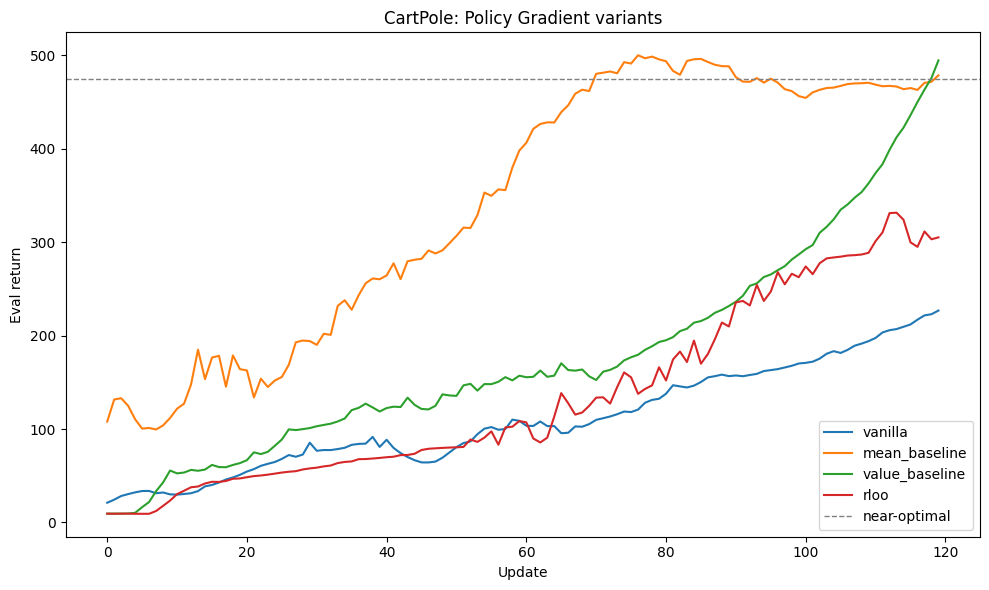

In [10]:
plt.figure(figsize=(10, 6))
for name, h in histories.items():
    plt.plot(h["eval_mean_return"], label=name)

plt.axhline(475, color="gray", linestyle="--", linewidth=1, label="near-optimal")
plt.xlabel("Update")
plt.ylabel("Eval return")
plt.title("CartPole: Policy Gradient variants")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
bc_full, bc_losses, n_full = train_bc(expert, seed=123, mode="full")

bc_prefix, _, n_prefix = train_bc(expert, seed=123, mode="prefix20")

bc_tiny, _, n_tiny = train_bc(expert, seed=123, n_episodes=10, mode="full")

bc_scores = {
    "BC full dataset": evaluate_policy(bc_full, env_seed=202, n_episodes=40),
    "BC limited prefix20": evaluate_policy(bc_prefix, env_seed=202, n_episodes=40),
    "BC tiny dataset (10 episodes)": evaluate_policy(bc_tiny, env_seed=202, n_episodes=40),
}

print("BC scores:")
for k, v in bc_scores.items():
    print(f"  {k}: {v:.2f}")
print(f"Dataset sizes: full={n_full}, prefix20={n_prefix}, tiny10={n_tiny}")


BC scores:
  BC full dataset: 490.95
  BC limited prefix20: 328.45
  BC tiny dataset (10 episodes): 357.55
Dataset sizes: full=97741, prefix20=4000, tiny10=4942


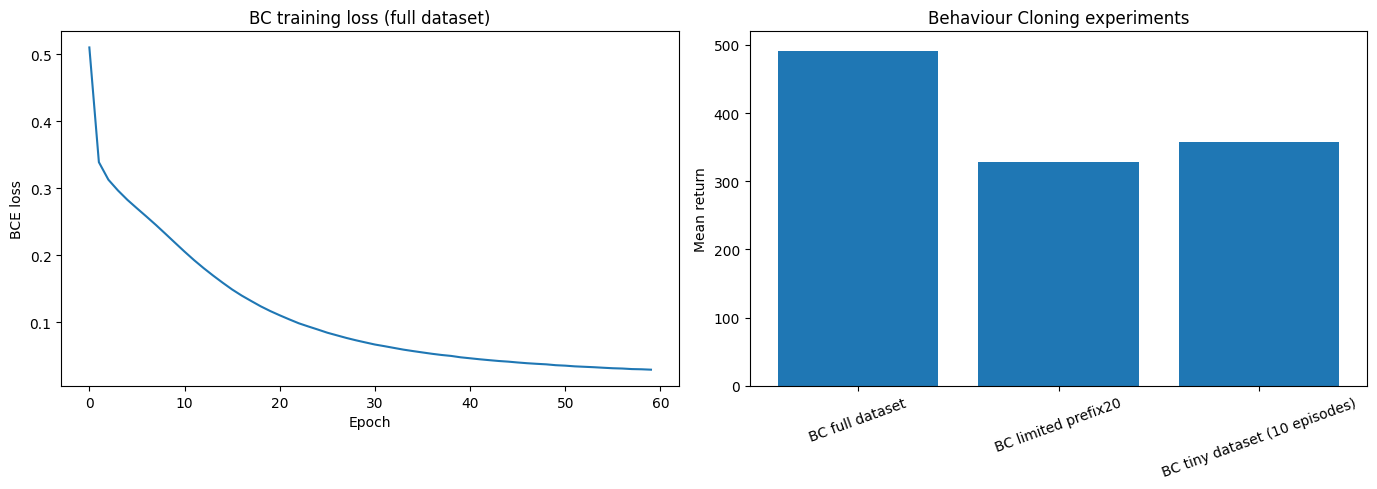

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bc_losses)
axes[0].set_title("BC training loss (full dataset)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")

labels = list(bc_scores.keys())
values = [bc_scores[k] for k in labels]
axes[1].bar(labels, values)
axes[1].set_ylim(0, 520)
axes[1].set_ylabel("Mean return")
axes[1].set_title("Behaviour Cloning experiments")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [14]:
out_dir = Path("results_week1_notebook")
out_dir.mkdir(exist_ok=True)

summary = {
    "config": cfg.__dict__,
    "pg_final_eval": finals,
    "pg_best_variant": best_name,
    "pg_best_eval": finals[best_name],
    "bc_dataset_sizes": {
        "full": n_full,
        "prefix20": n_prefix,
        "tiny_10eps": n_tiny,
    },
    "bc_scores": bc_scores,
}

with open(out_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print(f"\nSaved summary to: {out_dir / 'summary.json'}")


{
  "config": {
    "seed": 42,
    "updates": 120,
    "batch_steps": 2500,
    "gamma": 0.99,
    "hidden_dim": 32,
    "lr_policy": 0.002,
    "lr_value": 0.002,
    "entropy_start": 0.01,
    "entropy_end": 0.0
  },
  "pg_final_eval": {
    "vanilla": 226.75,
    "mean_baseline": 478.5,
    "value_baseline": 494.5,
    "rloo": 305.1
  },
  "pg_best_variant": "value_baseline",
  "pg_best_eval": 494.5,
  "bc_dataset_sizes": {
    "full": 97741,
    "prefix20": 4000,
    "tiny_10eps": 4942
  },
  "bc_scores": {
    "BC full dataset": 490.95,
    "BC limited prefix20": 328.45,
    "BC tiny dataset (10 episodes)": 357.55
  }
}

Saved summary to: results_week1_notebook/summary.json


1. В RL все 4 варианта достигают высокого качества на CartPole, но отличаются стабильностью/скоростью.
2. `Value baseline` обычно снижает variance лучше, чем константный baseline.
3. BC отлично работает на полном датасете эксперта.
4. BC деградирует при плохом покрытии состояний (`prefix20`) и малом объеме демонстраций (`tiny`).
